# Time-series analysis notebook (Phoenix context)

This notebook loads `timeseries.csv`, performs sanity checks, and runs a compact analysis pipeline tailored to *Heisenberg-evolution / projected-Krylov* style logs:

- `t`: time (assumed in units where your Hamiltonian prefactors live, e.g. `J t`)
- `obs`: primary observable expectation value (e.g. ⟨O(t)⟩)
- `tail_frac`: "leakage/tail fraction" style diagnostic (often tiny; plotted in log-scale)
- `rebuilt`: reconstructed / projected estimate (if present)

Everything is written to be reusable: if you swap the CSV for a larger run, it should still work with minimal edits.


In [1]:
cd /home/tomas/phoenix/

/home/tomas/phoenix


/usr/lib/python3/dist-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [4]:
import numpy as np
import qutip as qt

def heisenberg_XYZ_open(N: int, Jx: float, Jy: float, Jz: float) -> qt.Qobj:
    """Open-boundary XYZ chain: H = sum_{i=0}^{N-2} (Jx X_i X_{i+1} + Jy Y_i Y_{i+1} + Jz Z_i Z_{i+1})."""
    sx, sy, sz = qt.sigmax(), qt.sigmay(), qt.sigmaz()
    si = qt.qeye(2)

    def op_on_sites(op_i, i, op_j, j):
        ops = [si] * N
        ops[i] = op_i
        ops[j] = op_j
        return qt.tensor(ops)

    H = 0
    for i in range(N - 1):  # open BCs
        H += Jx * op_on_sites(sx, i, sx, i + 1)
        H += Jy * op_on_sites(sy, i, sy, i + 1)
        H += Jz * op_on_sites(sz, i, sz, i + 1)
    return qt.Qobj(H)

def sigma0_z_polarized(N: int) -> qt.Qobj:
    """Product density matrix |0><0|^{⊗N} (max +Z polarization, no x/y, no entanglement)."""
    ket0 = qt.basis(2, 0)          # |0> : +1 eigenstate of sigmaz
    rho0 = ket0 * ket0.dag()       # |0><0|
    return qt.tensor([rho0] * N)

def Sz0(N: int, site: int = 0) -> qt.Qobj:
    """Single-site observable σ^z_site (default site 0)."""
    sz = qt.sigmaz()
    si = qt.qeye(2)
    ops = [si] * N
    ops[site] = sz
    return qt.tensor(ops)

# --- Example usage ---
N = 10
Jx, Jy, Jz = 1.0, -1, 1e-2   # inputs
H = heisenberg_XYZ_open(N, Jx, Jy, Jz)

rho0 = sigma0_z_polarized(N)
O = Sz0(N, site=0)

# time grid, ħ=1 (QuTiP uses ħ=1 units by default)
tlist = np.linspace(0.0, 1.0, 100)

# Schrödinger picture: <O>(t) = Tr[ O ρ(t) ]
res = qt.mesolve(H, rho0, tlist, c_ops=[], e_ops=[O])
exp_Sz0_XYZ_N10 = np.array(res.expect[0])/2

print("⟨Sz0⟩(t=0) =", exp_Sz0[0])


⟨Sz0⟩(t=0) = 0.5


In [12]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from pathlib import Path
from dataclasses import dataclass

# Optional, used only if available
try:
    from scipy.optimize import curve_fit
except Exception:
    curve_fit = None

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

from pathlib import Path
import pandas as pd

path0 = "/home/tomas/phoenix/data/"

DATA_PATH = Path(
    path0
    +"20260205_145115__XY__N10__ell5__m2__eps1e-10__ptail2__dt1.000e-02__tmax1__seedZ0__sigma_HS"
    +"/timeseries.csv").expanduser()

df_raw = pd.read_csv(DATA_PATH)
df_raw.head(), df_raw.shape


(      t       obs     tail_frac  rebuilt
 0  0.00  5.000000  0.000000e+00      0.0
 1  0.01  4.992802  1.735305e-19      0.0
 2  0.02  4.971229  4.436409e-17      0.0
 3  0.03  4.935347  1.134441e-15      0.0
 4  0.04  4.885263  1.129585e-14      0.0,
 (101, 4))

In [13]:
# Load
df_raw = pd.read_csv(DATA_PATH)
df_raw.head(), df_raw.shape


(      t       obs     tail_frac  rebuilt
 0  0.00  5.000000  0.000000e+00      0.0
 1  0.01  4.992802  1.735305e-19      0.0
 2  0.02  4.971229  4.436409e-17      0.0
 3  0.03  4.935347  1.134441e-15      0.0
 4  0.04  4.885263  1.129585e-14      0.0,
 (101, 4))

In [14]:
# ---- Column detection / standardization ----
# Heuristic: pick time column among common names, else take the first numeric column.
COMMON_TIME_COLS = ["t", "time", "timestamp", "date", "datetime"]

def pick_time_column(df: pd.DataFrame) -> str:
    cols_lower = {c.lower(): c for c in df.columns}
    for c in COMMON_TIME_COLS:
        if c in cols_lower:
            return cols_lower[c]
    # fallback: first numeric column
    num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    if not num_cols:
        # parse first col as datetime
        return df.columns[0]
    return num_cols[0]

time_col = pick_time_column(df_raw)

# Parse time
df = df_raw.copy()
if pd.api.types.is_numeric_dtype(df[time_col]):
    df["t"] = df[time_col].astype(float)
else:
    df["t_dt"] = pd.to_datetime(df[time_col], errors="coerce", utc=True)
    if df["t_dt"].isna().any():
        raise ValueError(f"Could not parse time column '{time_col}' as datetime.")
    # Convert to seconds since start
    df["t"] = (df["t_dt"] - df["t_dt"].min()).dt.total_seconds()

# Candidate signal columns: numeric, excluding time
signal_cols = [c for c in df.columns if c not in [time_col, "t_dt", "t"] and pd.api.types.is_numeric_dtype(df[c])]
signal_cols


['obs', 'tail_frac', 'rebuilt']

In [15]:
# ---- Basic sanity checks ----
df = df.sort_values("t").reset_index(drop=True)

t = df["t"].to_numpy()
is_monotone = np.all(np.diff(t) > 0)
dt = np.diff(t)
dt_unique = np.unique(np.round(dt, 12)) if len(dt) else np.array([])

summary = {
    "n_rows": len(df),
    "time_col_original": time_col,
    "t_min": float(np.min(t)),
    "t_max": float(np.max(t)),
    "monotone_increasing": bool(is_monotone),
    "dt_unique": dt_unique.tolist(),
    "signal_cols": signal_cols,
}

summary


{'n_rows': 101,
 'time_col_original': 't',
 't_min': 0.0,
 't_max': 1.0,
 'monotone_increasing': True,
 'dt_unique': [0.01],
 'signal_cols': ['obs', 'tail_frac', 'rebuilt']}

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from pathlib import Path
from dataclasses import dataclass

# Optional, used only if available
try:
    from scipy.optimize import curve_fit
except Exception:
    curve_fit = None

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

from pathlib import Path
import pandas as pd

path0 = "/home/tomas/phoenix/data/"

DATA_PATH = Path(
    path0
    +"20260205_145115__XY__N10__ell5__m2__eps1e-10__ptail2__dt1.000e-02__tmax1__seedZ0__sigma_HS"
    +"/timeseries.csv").expanduser()

df_raw = pd.read_csv(DATA_PATH)
df_raw.head(), df_raw.shape


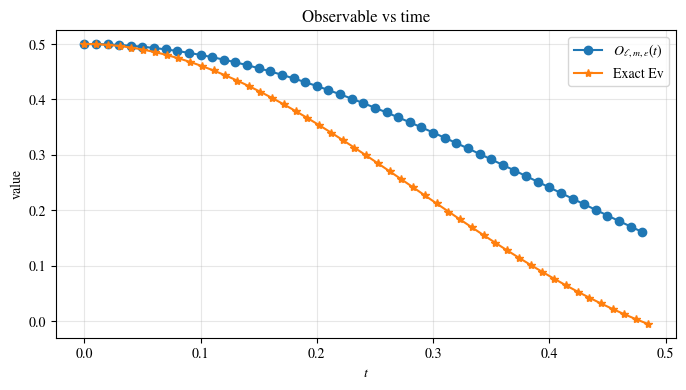

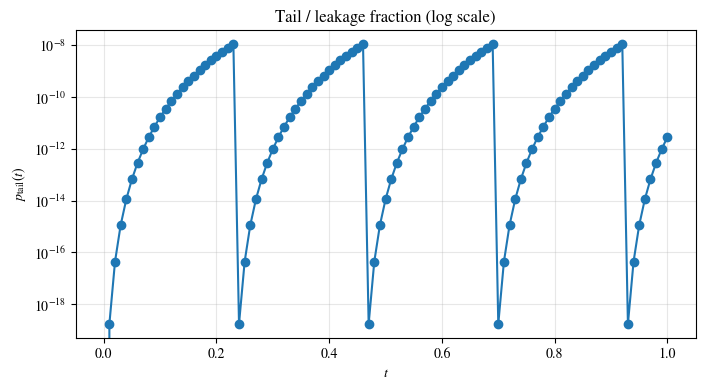

In [80]:
# ---- Quick plots (LaTeX labels) ----
import matplotlib.pyplot as plt

# Turn on LaTeX-style mathtext (no external LaTeX needed)
plt.rcParams.update({
    "text.usetex": False,          # set True only if you have a full LaTeX install
    "mathtext.fontset": "stix",
    "font.family": "STIXGeneral",
})

# Column picks
# If your observable column is literally named "obs", use it.
# Otherwise fall back to the first numeric signal.
obs_col = "obs" if "obs" in df.columns else (signal_cols[0] if signal_cols else None)
tail_col = "tail_frac" if "tail_frac" in df.columns else None
rebuilt_col = "rebuilt" if "rebuilt" in df.columns else None

assert obs_col is not None, "No numeric signal column found."

# Helper: escape underscores for non-math text; use $...$ for LaTeX math
def latex_label(col: str) -> str:
    # If you already pass a math expression like r"$O_{\ell,m,\epsilon}$", keep it.
    if col.startswith("$") and col.endswith("$"):
        return col
    # If you want a custom LaTeX name for a known column:
    if col == "obs":
        return r"$O_{\ell,m,\epsilon}(t)$"
    if col == "rebuilt":
        return r"$\widetilde{O}_{\ell,m,\epsilon}(t)$"
    if col == "tail_frac":
        return r"$p_{\mathrm{tail}}(t)$"
    # Otherwise: show as monospaced-ish text with escaped underscores
    return col.replace("_", r"\_")

# Observable vs time
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df["t"][:49], df[obs_col][:49], marker="o", label=latex_label(obs_col))

ax.plot(tlist[:49], res.expect[0][:49]/2, marker = "*", label = "Exact Ev")

ax.set_xlabel(r"$t$")
ax.set_ylabel(r"value")
ax.set_title(r"Observable vs time")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

# Tail fraction (log scale)
if tail_col is not None:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(df["t"], df[tail_col], marker="o")
    ax.set_yscale("log")
    ax.set_xlabel(r"$t$")
    ax.set_ylabel(latex_label(tail_col))
    ax.set_title(r"Tail / leakage fraction (log scale)")
    ax.grid(True, which="both", alpha=0.3)
    plt.show()


In [ ]:
# ---- Derived diagnostics ----
# Relative reconstruction error (if 'rebuilt' exists).
eps = 1e-12
if rebuilt_col is not None:
    rel_err = np.abs(df[rebuilt_col] - df[obs_col]) / (np.abs(df[obs_col]) + eps)
    df["rel_err_rebuilt_vs_obs"] = rel_err

# Finite-difference derivative of observable (useful to eyeball oscillations vs decay)
if len(df) >= 3:
    df["d_obs_dt_fd"] = np.gradient(df[obs_col].to_numpy(), df["t"].to_numpy())

# A compact view
cols_show = ["t", obs_col] + ([rebuilt_col] if rebuilt_col is not None else []) + ([tail_col] if tail_col is not None else [])
if "rel_err_rebuilt_vs_obs" in df.columns:
    cols_show += ["rel_err_rebuilt_vs_obs"]
if "d_obs_dt_fd" in df.columns:
    cols_show += ["d_obs_dt_fd"]

df[cols_show]


In [ ]:
# ---- Simple model fits (optional) ----
# Often, early-time decay in local observables can be roughly captured by an exponential:
#   y(t) = A * exp(-gamma * t) + C
# If your observable is oscillatory, you'd use:
#   y(t) = A * exp(-gamma * t) * cos(omega t + phi) + C
#
# With only ~10 points, treat fits as *descriptive*, not definitive.

if curve_fit is None:
    print("scipy not available; skipping fits.")
else:
    t = df["t"].to_numpy()
    y = df[obs_col].to_numpy()

    def exp_model(t, A, gamma, C):
        return A * np.exp(-gamma * t) + C

    # naive initialization
    A0 = y[0] - y[-1]
    C0 = y[-1]
    gamma0 = 1.0 / (t[-1] - t[0] + 1e-9)

    try:
        popt, pcov = curve_fit(exp_model, t, y, p0=[A0, gamma0, C0], maxfev=10000)
        A_hat, gamma_hat, C_hat = popt
        print({"A": A_hat, "gamma": gamma_hat, "C": C_hat})

        tt = np.linspace(t.min(), t.max(), 300)
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(t, y, "o", label="data")
        ax.plot(tt, exp_model(tt, *popt), label="exp fit")
        ax.set_xlabel("t")
        ax.set_ylabel(obs_col)
        ax.set_title("Exponential fit (descriptive)")
        ax.grid(True, alpha=0.3)
        ax.legend()
        plt.show()
    except Exception as e:
        print("Fit failed:", repr(e))


In [ ]:
# ---- Save a cleaned version for downstream work ----
OUT_PATH = Path("timeseries_clean.parquet")
df.to_parquet(OUT_PATH, index=False)
print("Wrote:", OUT_PATH.resolve())
